In [10]:
%matplotlib inline
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall

In [11]:
df = pd.read_csv("C:\\Users\\marco\\Desktop\\DM2\\df_postoutliers.csv")

In [12]:
numeric_df = df.select_dtypes(include=['number'])

In [13]:
leak = [c for c in df.columns if "PCIAT" in c] + ["sedentary_social_withdrawal"]
num = df.select_dtypes(include=['number'])
feature_cols = [c for c in num.columns if c not in leak and c != "sii"]
X = num[feature_cols].values
y = num["sii"].astype(int).values

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=29, stratify=y)  

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scl = StandardScaler()
X_train = scl.fit_transform(X_train)
X_test = scl.transform(X_test)

In [19]:
# ── Accorpamento classi: Moderate (2) + Severe (3) → "Moderate+Severe" ──────
# Motivazione: la classe Severe ha troppi pochi esempi (26 su 2522 nel test
# set originale a 4 classi) per essere appresa in modo affidabile da nessun
# modello. Si accorpa con Moderate per aumentare il supporto della fascia
# di rischio più alta, a scapito della granularità clinica.

y_train = np.where(y_train >= 2, 2, y_train)
y_test  = np.where(y_test  >= 2, 2, y_test)

class_names = ['None', 'Mild', 'Moderate+Severe']

print("Distribuzione classi (train):", Counter(y_train))
print("Distribuzione classi (test): ", Counter(y_test))

Distribuzione classi (train): Counter({0: 4056, 1: 1105, 2: 721})
Distribuzione classi (test):  Counter({0: 1739, 1: 474, 2: 309})


In [ ]:
#on y va con logistic

In [177]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [179]:
clf_log = LogisticRegression(random_state=0)
clf_log.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [181]:
y_pred = clf_log.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, target_names=class_names))

Accuracy 0.7018239492466296
F1-score [0.82828283 0.07633588 0.29934924]
                 precision    recall  f1-score   support

           None       0.72      0.97      0.83      1739
           Mild       0.40      0.04      0.08       474
Moderate+Severe       0.45      0.22      0.30       309

       accuracy                           0.70      2522
      macro avg       0.53      0.41      0.40      2522
   weighted avg       0.63      0.70      0.62      2522



In [183]:
clf_log.intercept_

array([ 1.16948767, -0.18907753, -0.98041015])

In [185]:
clf_log.coef_

array([[ 0.03986407,  0.0981067 ,  0.01859929,  0.05376423, -0.17792761,
        -0.06215204,  0.08616379, -0.0223948 , -0.05265226,  0.00092642,
         0.07448233, -0.02535278, -0.00124194, -0.12999873, -0.0145142 ,
        -0.05529032,  0.03049348, -0.03798954,  0.03839022, -0.03460526,
        -0.0477994 , -0.05074445,  0.04947614,  0.03666733, -0.03667283,
        -0.04054721,  0.041692  ,  0.04051396,  0.03669279, -0.03246552,
        -0.04312411, -0.04328074, -0.07311713,  0.09893254, -0.02030208,
         0.05591864, -0.08419262,  0.0206249 , -0.02068007, -0.3285412 ,
        -0.25894214],
       [ 0.02011065,  0.02989957, -0.02911483, -0.01592729,  0.14215572,
        -0.00502365,  0.00552269,  0.05958516,  0.05307228, -0.059792  ,
        -0.02102098,  0.00213228,  0.06217718,  0.05988518,  0.0379322 ,
        -0.0046547 ,  0.01203869, -0.04505325,  0.00357225, -0.03193929,
         0.05485845, -0.04285806, -0.04100193,  0.03339991,  0.03590939,
         0.14577311, -0.00083

In [187]:
from scipy.special import expit

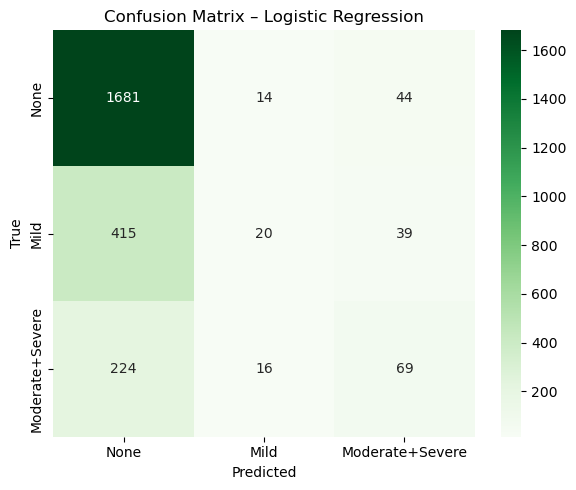

In [189]:
cf_log = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cf_log, annot=True, cmap="Greens", fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – Logistic Regression")
plt.tight_layout()
plt.savefig('logreg_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

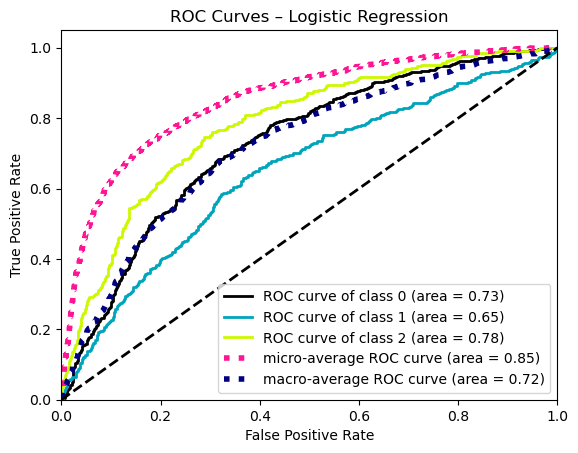

In [191]:
plot_roc(y_test, clf_log.predict_proba(X_test), title='ROC Curves – Logistic Regression')
plt.savefig('logreg_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#svm, cominciamo con pca

In [205]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

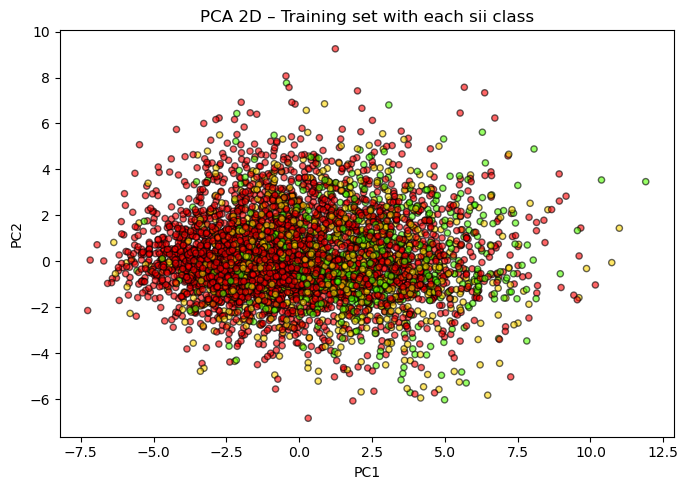

In [207]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
            cmap=plt.cm.prism, edgecolor='k', alpha=0.6, s=20)
plt.title('PCA 2D – Training set with each sii class')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('pca_2d_sii_classes.png', dpi=300, bbox_inches='tight')
plt.show()

In [199]:
from sklearn.svm import LinearSVC

param_grid_linsvc = {
    'C':    [0.001, 0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_linsvc = GridSearchCV(
    LinearSVC(class_weight='balanced', dual='auto', random_state=29, max_iter=5000),
    param_grid_linsvc, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_linsvc.fit(X_train, y_train)
print(f"Best params:      {grid_linsvc.best_params_}")
print(f"Best CV F1-macro: {grid_linsvc.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params:      {'C': 0.01, 'loss': 'squared_hinge'}
Best CV F1-macro: 0.4689


In [200]:
clf_linsvc = grid_linsvc.best_estimator_
y_pred_linsvc = clf_linsvc.predict(X_test)
# LinearSVC non ha predict_proba: uso decision_function (score, non probabilità calibrata)
y_score_linsvc = clf_linsvc.decision_function(X_test)   # shape (n_samples, 3)

print("=== LinearSVC – Classification Report ===")
print(classification_report(y_test, y_pred_linsvc, target_names=class_names))

=== LinearSVC – Classification Report ===
                 precision    recall  f1-score   support

           None       0.77      0.85      0.81      1739
           Mild       0.40      0.14      0.21       474
Moderate+Severe       0.37      0.50      0.42       309

       accuracy                           0.68      2522
      macro avg       0.51      0.50      0.48      2522
   weighted avg       0.65      0.68      0.65      2522



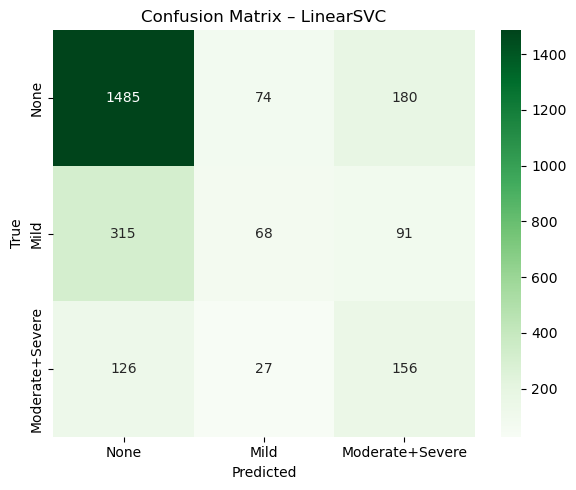

In [209]:
cf_linsvc = confusion_matrix(y_test, y_pred_linsvc)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cf_linsvc, annot=True, cmap="Greens", fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – LinearSVC")
plt.tight_layout()
plt.savefig('linsvc_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

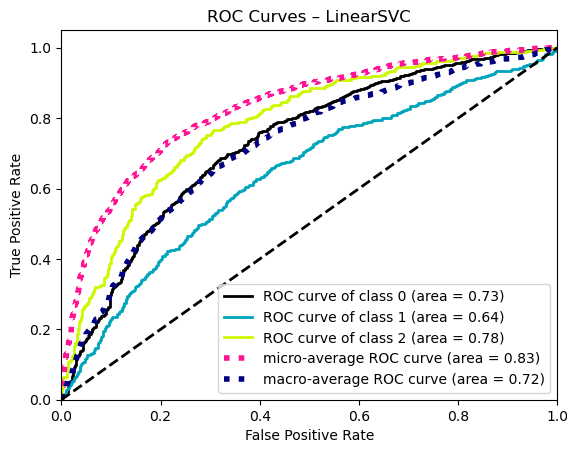

In [211]:
plot_roc(y_test, clf_linsvc.decision_function(X_test), title='ROC Curves – LinearSVC')
plt.savefig('linsvc_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [225]:
from sklearn.svm import SVC

In [227]:
param_grid_svc = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
}

# 1) Grid search VELOCE, senza probability=True (niente calibrazione Platt interna)
grid_svc = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=29),
    param_grid_svc, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_svc.fit(X_train, y_train)
print(f"Best params:      {grid_svc.best_params_}")
print(f"Best CV F1-macro: {grid_svc.best_score_:.4f}")

# 2) Rifitta UNA SOLA VOLTA con probability=True, solo sui migliori iperparametri
clf_svc = SVC(**grid_svc.best_params_, kernel='rbf',
              class_weight='balanced', probability=True, random_state=29)
clf_svc.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params:      {'C': 1, 'gamma': 'scale'}
Best CV F1-macro: 0.4843


SVC(C=1, class_weight='balanced', probability=True, random_state=29)

In [228]:
y_pred_svc  = clf_svc.predict(X_test)
y_proba_svc = clf_svc.predict_proba(X_test)   # ora funziona, usa il clf_svc rifittato con probability=True

print("=== SVC (RBF) – Classification Report ===")
print(classification_report(y_test, y_pred_svc, target_names=class_names))

=== SVC (RBF) – Classification Report ===
                 precision    recall  f1-score   support

           None       0.81      0.67      0.73      1739
           Mild       0.26      0.33      0.29       474
Moderate+Severe       0.32      0.49      0.38       309

       accuracy                           0.58      2522
      macro avg       0.46      0.50      0.47      2522
   weighted avg       0.65      0.58      0.61      2522



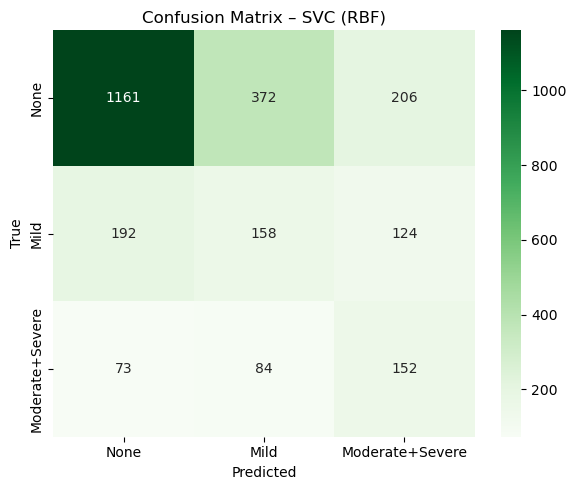

In [231]:
cf_svc = confusion_matrix(y_test, y_pred_svc)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cf_svc, annot=True, cmap="Greens", fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – SVC (RBF)")
plt.tight_layout()
plt.savefig('svc_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

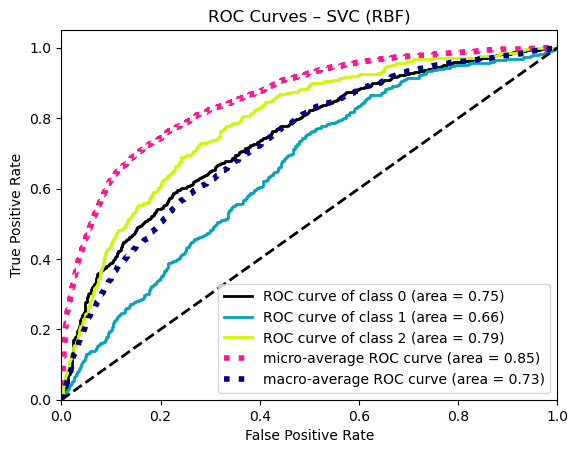

In [233]:
plot_roc(y_test, clf_svc.predict_proba(X_test), title='ROC Curves – SVC (RBF)')
plt.savefig('svc_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

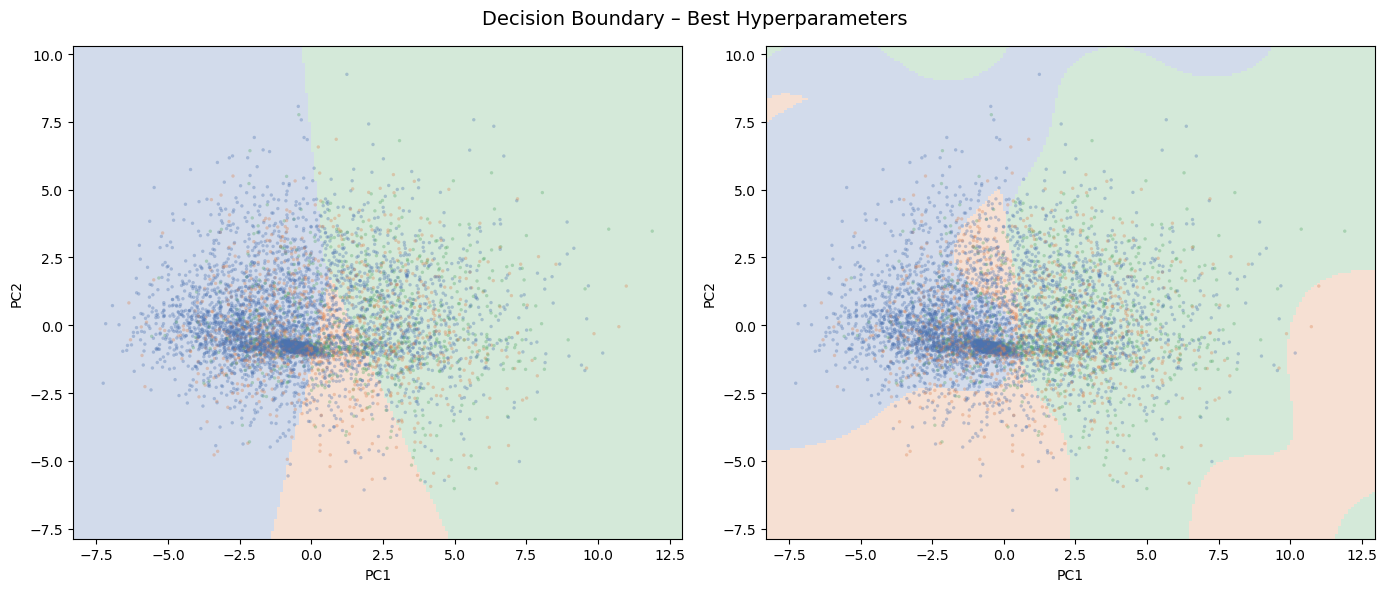

In [241]:
from matplotlib.colors import ListedColormap

# Colori discreti invece di una colormap continua, per evitare l'effetto "macchia"
class_colors = ListedColormap(['#4C72B0', '#DD8452', '#55A868'])  # blu/arancio/verde

best_C_linear = grid_linsvc.best_params_['C']
best_C_rbf    = grid_svc.best_params_['C']
best_gamma    = grid_svc.best_params_['gamma']

kernels_config = [
    ('linear', {'C': best_C_linear}),
    ('rbf',    {'C': best_C_rbf, 'gamma': best_gamma}),
]

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (kernel, params) in zip(axes, kernels_config):
    clf_vis = SVC(kernel=kernel, class_weight='balanced', **params)
    clf_vis.fit(X_pca, y_train)

    Z = clf_vis.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    ax.pcolormesh(XX, YY, Z, cmap=class_colors, alpha=0.25)

    # Punti senza bordo nero, più piccoli e più trasparenti: niente più "macchia"
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
               cmap=class_colors, s=6, alpha=0.35, linewidths=0)

    n_sv = len(clf_vis.support_vectors_)
    pct_sv = n_sv / len(X_pca) * 100
    title_params = ', '.join(f'{k}={v}' for k, v in params.items())
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Decision Boundary – Best Hyperparameters', fontsize=14)
plt.tight_layout()
plt.savefig('svm_decision_boundary_best_params.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#retinn

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
# ── Quick baseline, just to get a sense + look at the loss curve ───────────
clf_mlp_base = MLPClassifier(random_state=0, max_iter=500)
clf_mlp_base.fit(X_train, y_train)

plt.figure(figsize=(7, 4))
plt.plot(clf_mlp_base.loss_curve_)
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('MLP Baseline – Loss Curve')
plt.tight_layout()
plt.savefig('mlp_baseline_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'X_train' is not defined

In [248]:
# ── Tuning MLP (senza SMOTE) ─────────────────────────────────────────────
# MLPClassifier non supporta class_weight, quindi lo sbilanciamento viene
# gestito passando sample_weight='balanced' al fit: gli esempi delle classi
# rare pesano di piu' nella loss, senza generare dati sintetici.
param_list_mlp = {
    'hidden_layer_sizes': [(64, 32), (128, 64, 32), (100, 100), (64,)],
    'alpha':              [0.0001, 0.001, 0.01, 0.1],
    'activation':         ['relu', 'tanh'],
    'learning_rate':      ['constant', 'adaptive'],
}

mlp = MLPClassifier(random_state=0, max_iter=1000, early_stopping=True,
                    n_iter_no_change=15, validation_fraction=0.1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search_mlp = RandomizedSearchCV(
    mlp, param_distributions=param_list_mlp,
    n_iter=20, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1, random_state=42
)

# pesi bilanciati calcolati sul training set
sw_train = compute_sample_weight(class_weight='balanced', y=y_train)
random_search_mlp.fit(X_train, y_train, sample_weight=sw_train)

print(f"Best params:      {random_search_mlp.best_params_}")
print(f"Best CV F1-macro: {random_search_mlp.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params:      {'mlp__learning_rate': 'adaptive', 'mlp__hidden_layer_sizes': (100, 100), 'mlp__alpha': 0.1, 'mlp__activation': 'tanh'}
Best CV F1-macro: 0.4782


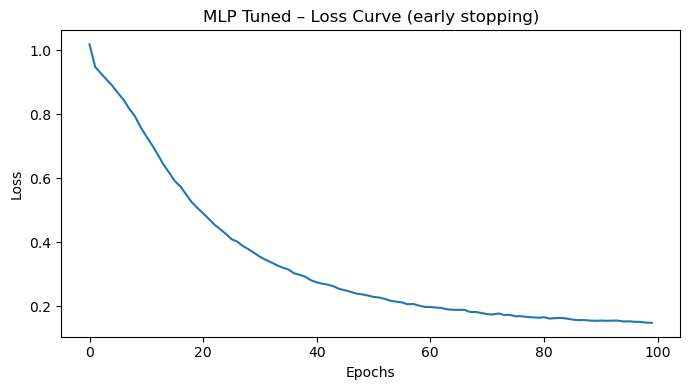

In [250]:
clf_mlp = random_search_mlp.best_estimator_

# Loss curve del modello finale (accessibile tramite lo step 'mlp' della pipeline)
plt.figure(figsize=(7, 4))
plt.plot(clf_mlp.named_steps['mlp'].loss_curve_)
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('MLP Tuned – Loss Curve (early stopping)')
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [251]:
y_pred_mlp  = clf_mlp.predict(X_test)
y_proba_mlp = clf_mlp.predict_proba(X_test)

print("=== MLP (SMOTE + tuning) – Classification Report ===")
print(classification_report(y_test, y_pred_mlp, target_names=class_names))

=== MLP (SMOTE + tuning) – Classification Report ===
                 precision    recall  f1-score   support

           None       0.80      0.77      0.78      1739
           Mild       0.29      0.31      0.30       474
Moderate+Severe       0.36      0.39      0.38       309

       accuracy                           0.63      2522
      macro avg       0.48      0.49      0.49      2522
   weighted avg       0.65      0.63      0.64      2522



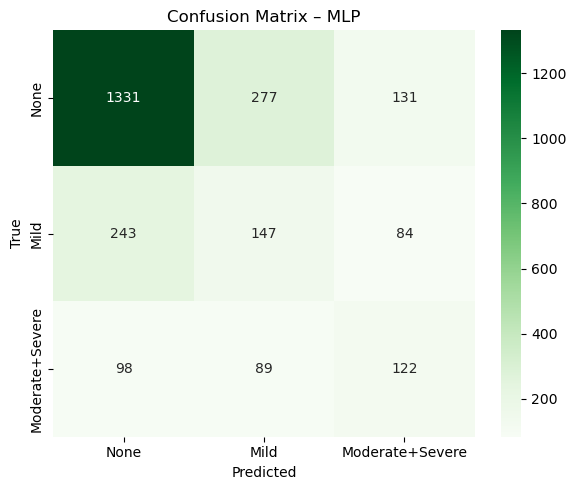

In [257]:
cf_mlp = confusion_matrix(y_test, y_pred_mlp)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cf_mlp, annot=True, cmap="Greens", fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – MLP")
plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

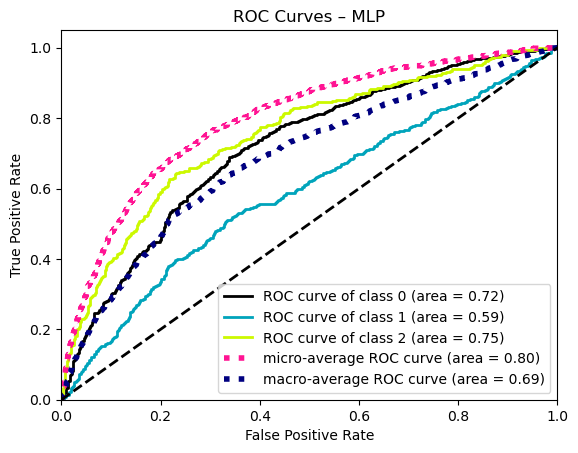

In [259]:
plot_roc(y_test, clf_mlp.predict_proba(X_test), title='ROC Curves – MLP')
plt.savefig('mlp_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

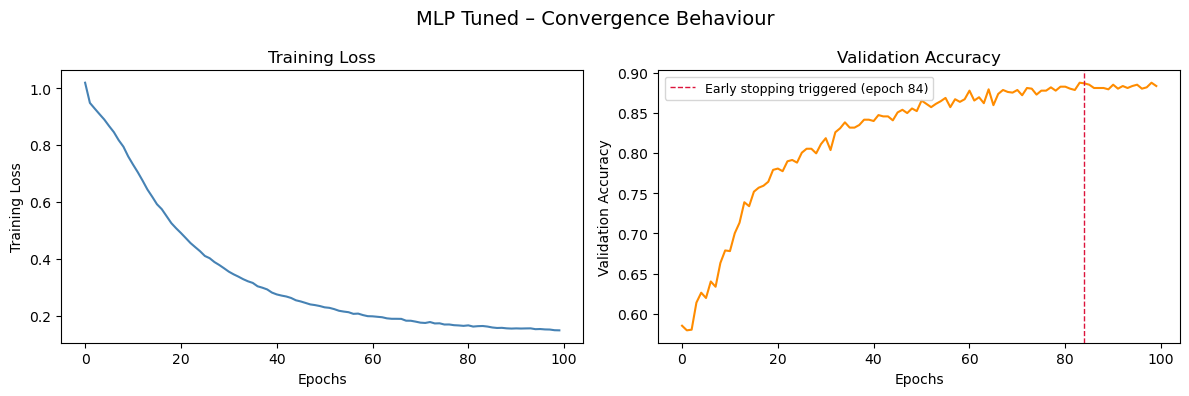

Training stopped at epoch 100 (no improvement in validation accuracy for 15 consecutive epochs, best epoch: 84)


In [265]:
mlp_best = clf_mlp.named_steps['mlp']

best_epoch = len(mlp_best.validation_scores_) - mlp_best.n_iter_no_change - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mlp_best.loss_curve_, color='steelblue')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss')

axes[1].plot(mlp_best.validation_scores_, color='darkorange')
axes[1].axvline(best_epoch, color='crimson', linestyle='--', lw=1,
                label=f'Early stopping triggered (epoch {best_epoch})')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend(fontsize=9)

plt.suptitle('MLP Tuned – Convergence Behaviour', fontsize=14)
plt.tight_layout()
plt.savefig('mlp_convergence_train_val.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Training stopped at epoch {mlp_best.n_iter_} "
      f"(no improvement in validation accuracy for {mlp_best.n_iter_no_change} consecutive epochs, "
      f"best epoch: {best_epoch})")

In [ ]:
#Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, f1_score)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

feature_names = feature_cols
# NON ridefinire class_names/colors qui: usa quelli già impostati nella cella
# di merge (3 classi: 'None', 'Mild', 'Moderate+Severe')

In [21]:
param_list_rf = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None] + list(np.arange(2, 20)),
    'max_features':     ['sqrt', 'log2', 4],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion':        ['gini', 'entropy'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=0, n_jobs=-1),
    param_distributions=param_list_rf,
    n_iter=30,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
    verbose=2,
    random_state=42
)
random_search_rf.fit(X_train, y_train)
print(f"Best params:      {random_search_rf.best_params_}")
print(f"Best CV F1-macro: {random_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:      {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 18, 'criterion': 'entropy'}
Best CV F1-macro: 0.7756


In [22]:
clf_rf      = random_search_rf.best_estimator_
y_pred_rf   = clf_rf.predict(X_test)
y_proba_rf  = clf_rf.predict_proba(X_test)
print("=== Random Forest – Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

=== Random Forest – Classification Report ===
                 precision    recall  f1-score   support

           None       0.88      0.98      0.93      1739
           Mild       0.90      0.66      0.76       474
Moderate+Severe       0.84      0.62      0.72       309

       accuracy                           0.88      2522
      macro avg       0.87      0.76      0.80      2522
   weighted avg       0.88      0.88      0.87      2522



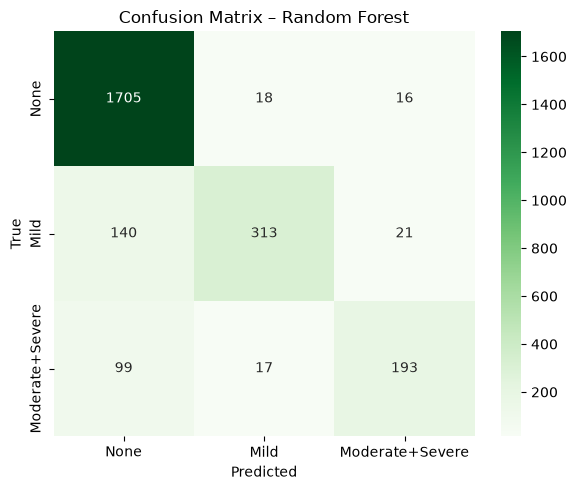

In [23]:
cf_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cf_rf, annot=True, cmap="Greens", fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – Random Forest")
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
plot_roc(y_test, clf_rf.predict_proba(X_test), title='ROC Curves – Random Forest')
plt.savefig('rf_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'plot_roc' is not defined

In [ ]:
nbr_features = 15
tree_feature_importances = clf_rf.feature_importances_
sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(np.arange(nbr_features), tree_feature_importances[sorted_idx],
        color='steelblue', edgecolor='k', alpha=0.85)
ax.set_yticks(np.arange(nbr_features))
ax.set_yticklabels(np.array(feature_names)[sorted_idx])
ax.set_title('Random Forest – Feature Importances MDI (Top 15)', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('rf_feature_importance_mdi.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# IMPORTANTE: scoring esplicito, altrimenti permutation_importance usa
# di default l'accuracy (score() del modello), non F1-macro come dice l'asse
result_perm = permutation_importance(
    clf_rf, X_test, y_test,
    scoring='f1_macro',
    n_repeats=10, random_state=42, n_jobs=-1
)
sorted_idx_perm = result_perm.importances_mean.argsort()[-nbr_features:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(result_perm.importances[sorted_idx_perm].T,
           vert=False,
           labels=np.array(feature_names)[sorted_idx_perm])
ax.set_title('Permutation Importances – Random Forest (Top 15)', fontsize=13)
ax.set_xlabel('Decrease in F1-macro')
plt.tight_layout()
plt.savefig('rf_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))
for ax, idx in zip(axes, [0, 1]):
    plot_tree(clf_rf.estimators_[idx],
              feature_names=feature_names,
              class_names=class_names,
              filled=True,
              rounded=True,
              fontsize=8,
              max_depth=2,
              ax=ax)
    ax.set_title(f'Tree #{idx} (max_depth=2)', fontsize=13)
plt.suptitle('Example Trees from the Forest', fontsize=15)
plt.tight_layout()
plt.savefig('rf_example_trees.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
n_estimators_list = [10, 25, 50, 100, 200]
f1_scores = []
for n in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=0,
        n_jobs=-1,
        **{k: v for k, v in random_search_rf.best_params_.items()
           if k != 'n_estimators'}
    )
    rf.fit(X_train, y_train)
    f1_scores.append(f1_score(y_test, rf.predict(X_test), average='macro'))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimators_list, f1_scores, marker='o', color='steelblue', lw=2)
ax.set_title('F1-macro vs Number of Estimators', fontsize=13)
ax.set_xlabel('n_estimators')
ax.set_ylabel('F1-macro')
plt.tight_layout()
plt.savefig('rf_n_estimators_vs_f1.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Gradient Boosting

In [287]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, f1_score)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance

param_list_gb = {
    'n_estimators':      [50, 100, 200],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [2, 3, 4, 5],
    'subsample':         [0.6, 0.8, 1.0],
    'max_features':      ['sqrt', 'log2', None],
    'min_samples_leaf':  [1, 5, 10, 20],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=0),
    param_distributions=param_list_gb,
    n_iter=20,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
    verbose=2,
    random_state=42
)
random_search_gb.fit(X_train, y_train)
print(f"Best params:      {random_search_gb.best_params_}")
print(f"Best CV F1-macro: {random_search_gb.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params:      {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.2}
Best CV F1-macro: 0.8778


In [288]:
clf_gb     = random_search_gb.best_estimator_
y_pred_gb  = clf_gb.predict(X_test)
y_proba_gb = clf_gb.predict_proba(X_test)

print("=== Gradient Boosting – Classification Report ===")
print(classification_report(y_test, y_pred_gb, target_names=class_names))

=== Gradient Boosting – Classification Report ===
                 precision    recall  f1-score   support

           None       0.94      0.97      0.95      1739
           Mild       0.88      0.82      0.85       474
Moderate+Severe       0.88      0.76      0.82       309

       accuracy                           0.92      2522
      macro avg       0.90      0.85      0.87      2522
   weighted avg       0.92      0.92      0.92      2522



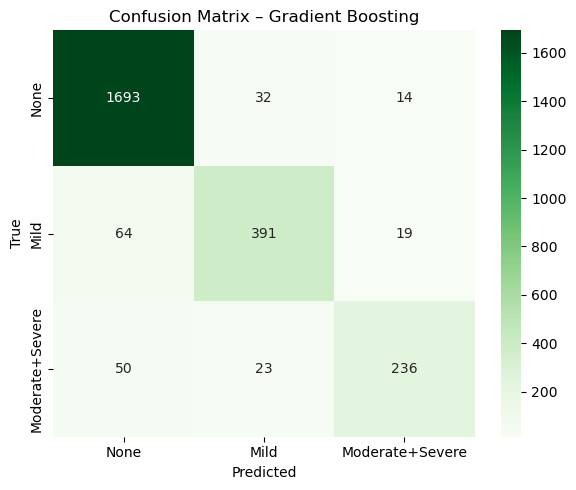

In [293]:
cf_gb = confusion_matrix(y_test, y_pred_gb)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cf_gb, annot=True, cmap="Greens", fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – Gradient Boosting")
plt.tight_layout()
plt.savefig('gb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

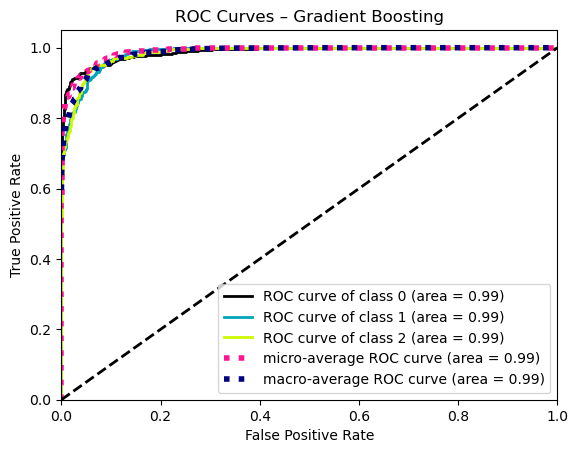

In [300]:
plot_roc(y_test, clf_gb.predict_proba(X_test), title='ROC Curves – Gradient Boosting')
plt.savefig('gb_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

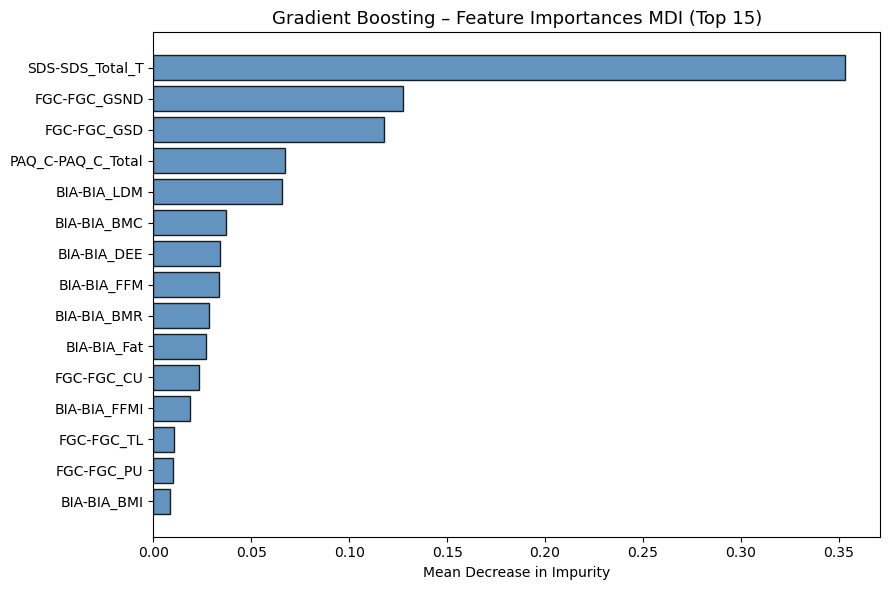

In [292]:
nbr_features = 15
gb_feature_importances = clf_gb.feature_importances_
sorted_idx = gb_feature_importances.argsort()[-nbr_features:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(np.arange(nbr_features), gb_feature_importances[sorted_idx],
        color='steelblue', edgecolor='k', alpha=0.85)
ax.set_yticks(np.arange(nbr_features))
ax.set_yticklabels(np.array(feature_names)[sorted_idx])
ax.set_title('Gradient Boosting – Feature Importances MDI (Top 15)', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('gb_feature_importance_mdi.png', dpi=300, bbox_inches='tight')
plt.show()

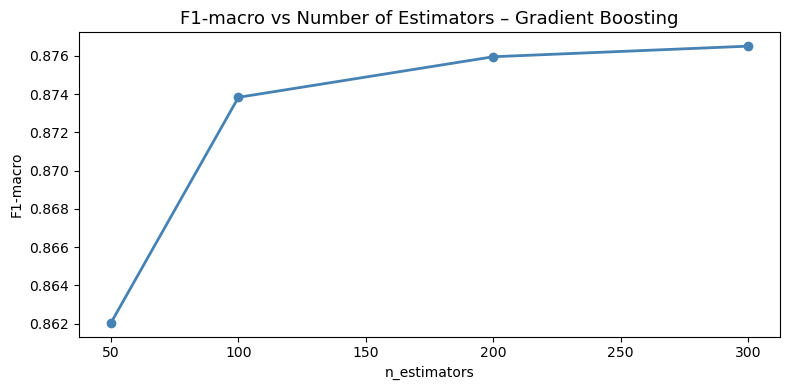

In [294]:
# Effetto del numero di stimatori (stesso confronto fatto per Random Forest)
n_estimators_list = [50, 100, 200, 300]
f1_scores_gb = []
for n in n_estimators_list:
    gb = GradientBoostingClassifier(
        n_estimators=n, random_state=0,
        **{k: v for k, v in random_search_gb.best_params_.items() if k != 'n_estimators'}
    )
    gb.fit(X_train, y_train)
    f1_scores_gb.append(f1_score(y_test, gb.predict(X_test), average='macro'))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimators_list, f1_scores_gb, marker='o', color='steelblue', lw=2)
ax.set_title('F1-macro vs Number of Estimators – Gradient Boosting', fontsize=13)
ax.set_xlabel('n_estimators')
ax.set_ylabel('F1-macro')
plt.tight_layout()
plt.savefig('gb_n_estimators_vs_f1.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
#Tabella Conclusiva

In [ ]:
from sklearn.metrics import precision_score, f1_score, roc_auc_score

# tutti i classificatori del Modulo 2 (oggetti gia' fittati)
modelli = {
    'Logistic Regression': clf_log,
    'SVM':                  clf_svm,
    'Neural Network':       clf_nn,
    'Random Forest':        clf_rf,
    'Bagging':              clf_bag,
    'AdaBoost':             clf_ada,
    'Gradient Boosting':    clf_gb,
    'HistGradient Boosting':clf_hgb,
    'XGBoost':              clf_xgb,
    'LightGBM':             clf_lgb,
    'CatBoost':             clf_cat,
}

rows = []
for nome, clf in modelli.items():
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    rows.append({
        'Model':               nome,
        'Precision (macro)':   precision_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 (macro)':          f1_score(y_test, y_pred, average='macro', zero_division=0),
        'ROC-AUC (OvR macro)': roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
    })

final_table = (pd.DataFrame(rows)
               .set_index('Model')
               .sort_values('F1 (macro)', ascending=False))
print(final_table.round(3).to_string())

# heatmap opzionale
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(final_table, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Modulo 2 – Confronto classificatori', fontsize=13)
plt.tight_layout(); plt.show()

In [31]:
import joblib
joblib.dump(clf_rf, r'C:\Users\marco\Desktop\DM2\clf_rf.pkl')

['C:\\Users\\marco\\Desktop\\DM2\\clf_rf.pkl']